In [19]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical


dataset_dir = "/kaggle/input/datasets/orvile/gastrovision-gastrointestinal-disease-detection/Gastrovision"
IMG_SIZE = (128, 128)
NUM_CLASSES = 27

X = []   # images
y = []   # labels



In [20]:
class_names = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d)) and d != "Accessory tools"])
print(f"✅ Found {len(class_names)} classes:", class_names)
for label, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_dir, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_file in images:
        img_path = os.path.join(class_path, img_file)
        img = load_img(img_path, target_size=IMG_SIZE)
        img_array = img_to_array(img) / 255.0
        X.append(img_array)
        y.append(label)

X = np.array(X, dtype="float32")
y = np.array(y)
print(f"\n✅ Loaded {len(X)} images of shape {X.shape}.")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat = to_categorical(y_val, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)
print(f"\n📊 Dataset split: {len(X_train)} train | {len(X_val)} val | {len(X_test)} test")

✅ Found 26 classes: ['Angiectasia', 'Barretts esophagus', 'Blood in lumen', 'Cecum', 'Colon diverticula', 'Colon polyps', 'Colorectal cancer', 'Duodenal bulb', 'Dyed-lifted-polyps', 'Dyed-resection-margins', 'Erythema', 'Esophageal varices', 'Esophagitis', 'Gastric polyps', 'Gastroesophageal_junction_normal z-line', 'Ileocecal valve', 'Mucosal inflammation large bowel', 'Normal esophagus', 'Normal mucosa and vascular pattern in the large bowel', 'Normal stomach', 'Pylorus', 'Resected polyps', 'Resection margins', 'Retroflex rectum', 'Small bowel_terminal ileum', 'Ulcer']

✅ Loaded 6734 images of shape (6734, 128, 128, 3).

📊 Dataset split: 4713 train | 1010 val | 1011 test


In [21]:
def build_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model




In [22]:
model = build_cnn()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-11 08:29:47.350548: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,490,971 (32.39 MB)

 Trainable params: 8,490,011 (32.39 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 146s 960ms/step - accuracy: 0.4053 - loss: 2.2142 - val_accuracy: 0.2574 - val_loss: 4.1504
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 146s 988ms/step - accuracy: 0.4802 - loss: 1.7407 - val_accuracy: 0.2426 - val_loss: 3.3179
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 141s 951ms/step - accuracy: 0.5116 - loss: 1.5300 - val_accuracy: 0.4198 - val_loss: 2.1422
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 145s 978ms/step - accuracy: 0.5693 - loss: 1.3644 - val_accuracy: 0.4109 - val_loss: 2.0677
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 144s 972ms/step - accuracy: 0.5829 - loss: 1.2789 - val_accuracy: 0.4980 - val_loss: 1.7775
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 143s 969ms/step - accuracy: 0.6113 - loss: 1.1783 - val_accuracy: 0.4356 - val_loss: 2.3133
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 141s 955ms/step - accuracy: 0.6194 - loss: 1.1375 - val_accuracy: 0.4782 - val_loss: 1.8423
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 144s 970ms/step - accuracy: 0.6463 -

In [23]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n⚙️ Precision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step

📋 Classification Report:
                                                       precision    recall  f1-score   support

                                          Angiectasia     0.0000    0.0000    0.0000         2
                                   Barretts esophagus     0.5000    0.2667    0.3478        15
                                       Blood in lumen     0.3514    0.5000    0.4127        26
                                                Cecum     0.0000    0.0000    0.0000        17
                                    Colon diverticula     0.0000    0.0000    0.0000         4
                                         Colon polyps     0.2870    0.8049    0.4231       123
                                    Colorectal cancer     0.1667    0.1429    0.1538        21
                                        Duodenal bulb     0.6000    0.0968    0.1667        31
                                   Dyed-lifted-polyps     0.2222    0.0952   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

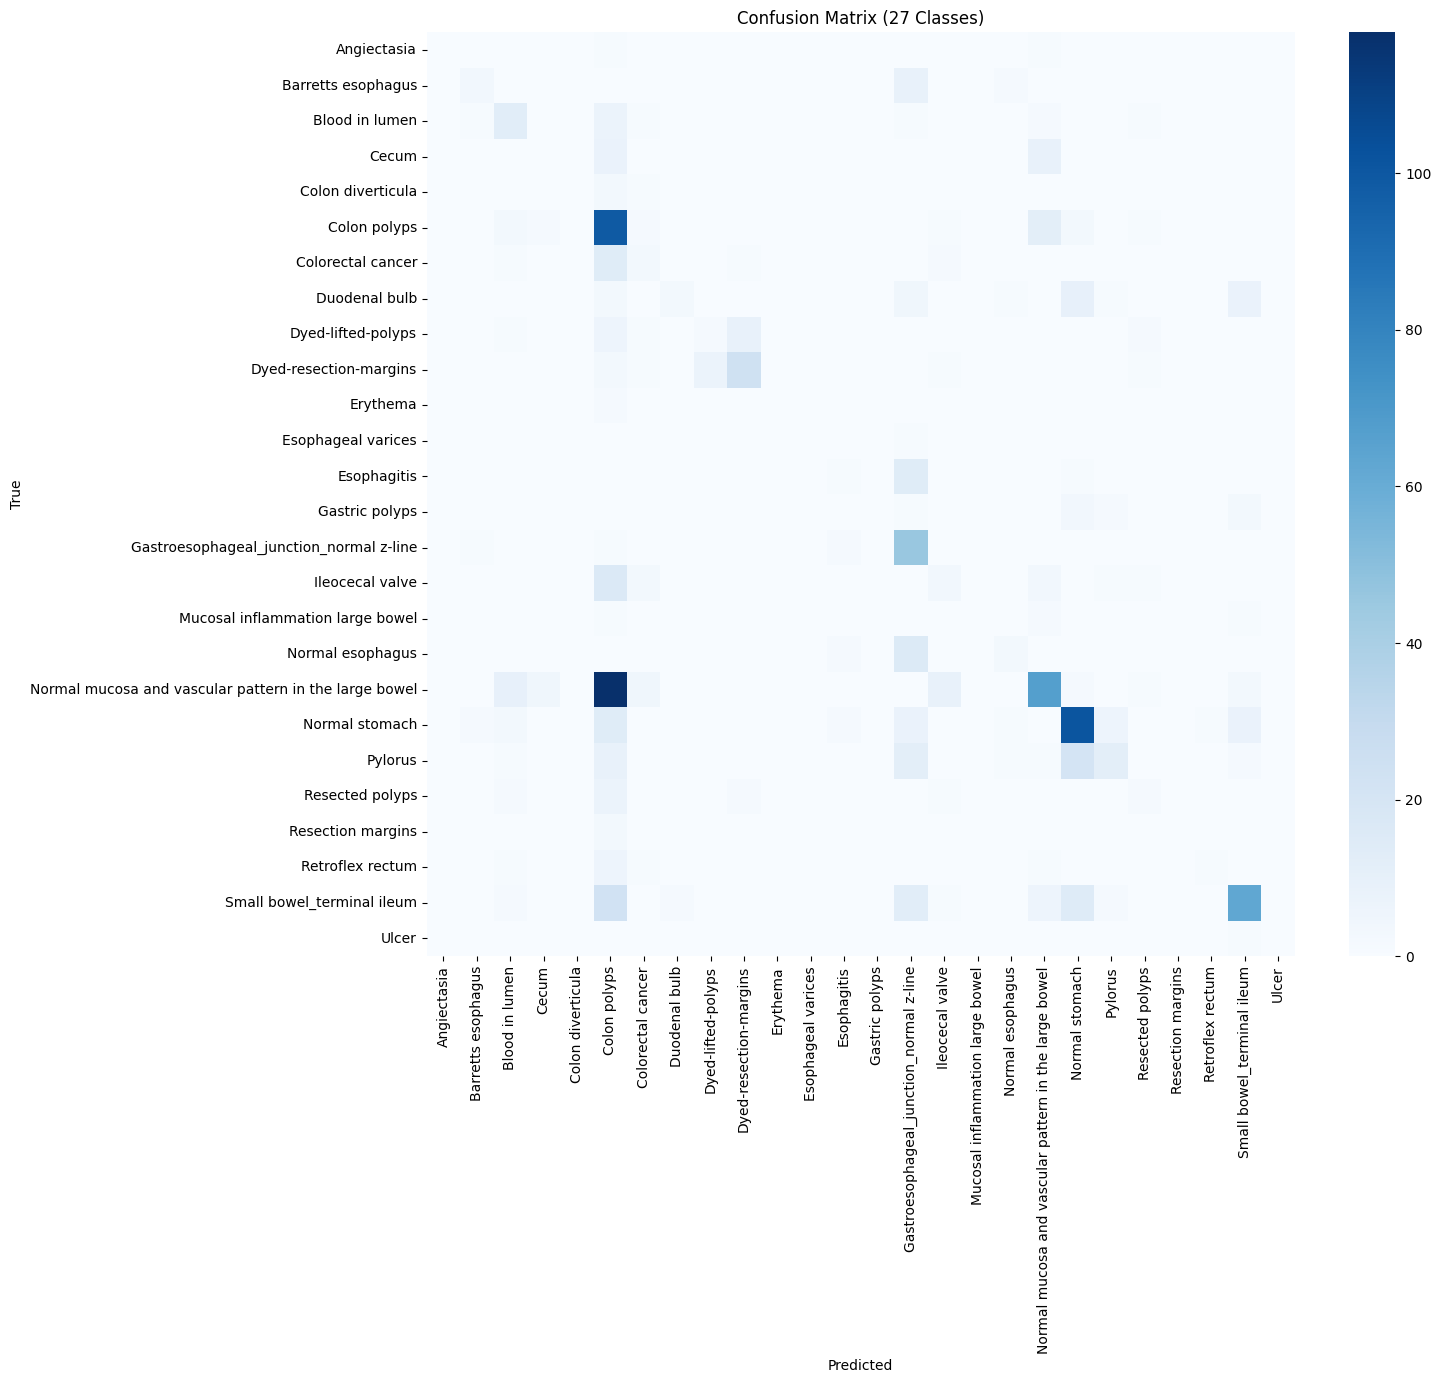

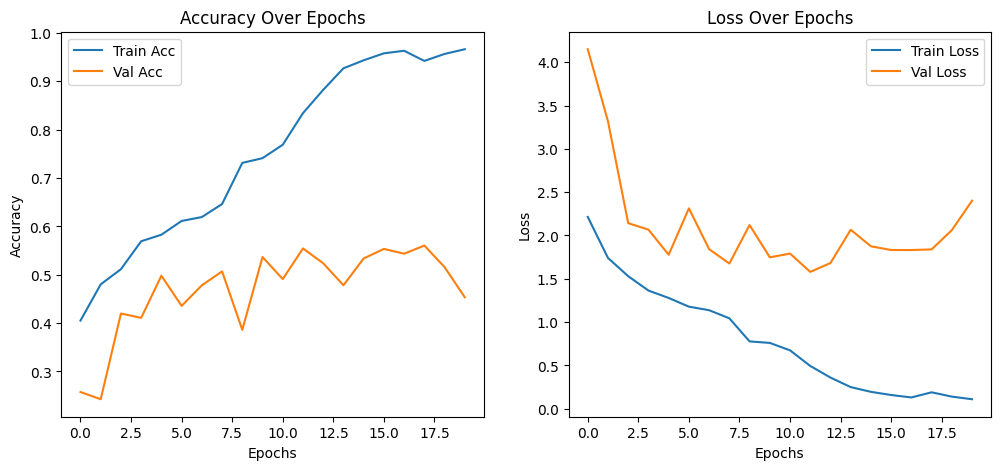


💾 Model saved as cnn_gastrovision_numpy.h5


In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (27 Classes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy Over Epochs'); plt.xlabel('Epochs'); plt.ylabel('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss Over Epochs'); plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.show()


model.save("/kaggle/working/cnn_gastrovision_numpy.h5")
print("\n💾 Model saved as cnn_gastrovision_numpy.h5")

In [25]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\n Final Training Accuracy: {train_acc:.4f}")
print(f" Final Validation Accuracy: {val_acc:.4f}")
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

# Print accuracy clearly
print(f" Test Accuracy: {test_acc*100:.2f}%")
print(f" Test Loss: {test_loss:.4f}")


 Final Training Accuracy: 0.9665
 Final Validation Accuracy: 0.4535
 Test Accuracy: 44.31%
 Test Loss: 2.5307
